# 7 — Input–ESN–OOF Correspondence Analysis

This notebook moves beyond final \(R^2\) and NRMSE values. It investigates the complete chain:

\[
\text{experimental condition}
\rightarrow \text{thermal input dynamics}
\rightarrow \text{ESN dynamics}
\rightarrow \text{one OOF effusivity prediction per trial}.
\]

It creates four complementary comparisons:

1. **Different representative materials at one temperature** — a readable target contrast.
2. **All 14 materials grouped as low, medium and high effusivity** — complete material coverage.
3. **One material across temperatures** — operating-condition sensitivity.
4. **Repeated trials at one material and temperature** — repeatability.

The notebook loads the saved **LOMO ESN OOF predictions** from AUX-BB. It does not perform hyperparameter optimization and does not pretend that effusivity is predicted at every timestep. Actual and predicted effusivity are trial-level values drawn across each trial block only for visual alignment.

# 1. Imports and analysis configuration

In [40]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import linalg
from scipy.signal import savgol_filter
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import spearmanr
from matplotlib.colors import TwoSlopeNorm
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.20,
})

TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
PARAMETER_TARGET = "eff"

# Main display selections. Change these without rerunning OOF modeling.
# Use the canonical dataset name: e.g. ps_foam, pu_foam, cork, gypsum,
# wood, pdms, cement, bismuth, graphite, titanium, nickel, iron,
# aluminum or copper.
SELECTED_SAMPLE = "aluminum"
SELECTED_TEMPERATURE = "40C"

# The all-material comparison is made at this temperature.
FIXED_TEMPERATURE = SELECTED_TEMPERATURE

# Both sample-specific analyses follow the same selection above.
TEMPERATURE_COMPARISON_MATERIAL = SELECTED_SAMPLE
REPETITION_COMPARISON_MATERIAL = SELECTED_SAMPLE
REPETITION_COMPARISON_TEMPERATURE = SELECTED_TEMPERATURE

DISPLAY_SEED = 42
MAXIMUM_DISPLAY_UNITS = 6

# These must match the AUX-BB run that produced the selected OOF CSV.
# Set both to None when using the exact saved AUX recommendation.
OVERRIDE_RES_SIZE = 20
OVERRIDE_WASHOUT = 0

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (cwd, cwd.parent) if (p / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run from the project root or notebooks directory.")

DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"
RESULTS_DIR = PROJECT_ROOT / "results" / "multi_temp_esn"
DIAGNOSTIC_DIR = PROJECT_ROOT / "results" / "input_esn_oof_diagnostics"
DIAGNOSTIC_DIR.mkdir(parents=True, exist_ok=True)

temperature_tag = "-".join(TEMPERATURE_FOLDERS)
PARAMETER_FILE = RESULTS_DIR / (
    f"{temperature_tag}_{PARAMETER_TARGET}"
    "_aux_baseline_centered_optuna_tpe_mlflow_parameters.json"
)
OOF_FILE = RESULTS_DIR / (
    f"{temperature_tag}_{PARAMETER_TARGET}"
    "_aux_bb_fixed_analysis_held_out_material_esn_eff_oof_predictions.csv"
)

for path in (PARAMETER_FILE, OOF_FILE):
    if not path.is_file():
        raise FileNotFoundError(path)

with PARAMETER_FILE.open() as file:
    SAVED_CONFIGURATION = json.load(file)

ANALYSIS_WINDOW = tuple(SAVED_CONFIGURATION["analysis_window"]) 
saved_esn = SAVED_CONFIGURATION["esn_parameters"]
ESN_RES_SIZE = int(saved_esn["res_size"] if OVERRIDE_RES_SIZE is None else OVERRIDE_RES_SIZE)
ESN_LEAK_RATE = float(saved_esn["leak_rate"])
ESN_INPUT_MAGNITUDE = float(saved_esn["input_magnitude"])
ESN_SPECTRAL_RADIUS = float(saved_esn["spectral_radius"])
ESN_WASHOUT = int(saved_esn["washout"] if OVERRIDE_WASHOUT is None else OVERRIDE_WASHOUT)

OOF = pd.read_csv(OOF_FILE)
required_oof = {
    "trial_id", "Temperature", "Temperature_C", "Sample", "Trial", "y_true", "y_pred"
}
missing = required_oof - set(OOF.columns)
if missing:
    raise KeyError(f"OOF file is missing columns: {sorted(missing)}")

available_samples = sorted(OOF["Sample"].unique())
if SELECTED_SAMPLE not in available_samples:
    raise KeyError(
        f"Unknown SELECTED_SAMPLE={SELECTED_SAMPLE!r}. "
        f"Choose one of: {available_samples}"
    )
if SELECTED_TEMPERATURE not in TEMPERATURE_FOLDERS:
    raise KeyError(
        f"Unknown SELECTED_TEMPERATURE={SELECTED_TEMPERATURE!r}. "
        f"Choose one of: {TEMPERATURE_FOLDERS}"
    )

print("OOF predictions:", OOF_FILE)
print("Rows:", len(OOF), "| Materials:", OOF["Sample"].nunique())
print("Available samples:", available_samples)
print("Selected sample:", SELECTED_SAMPLE)
print("Selected temperature:", SELECTED_TEMPERATURE)
print("Analysis window:", ANALYSIS_WINDOW)
print("Diagnostic reservoir:", {
    "res_size": ESN_RES_SIZE,
    "leak_rate": ESN_LEAK_RATE,
    "input_magnitude": ESN_INPUT_MAGNITUDE,
    "spectral_radius": ESN_SPECTRAL_RADIUS,
    "washout": ESN_WASHOUT,
    "seed": DISPLAY_SEED,
})
print("Important: overrides must match the AUX-BB run used to create the OOF CSV.")

OOF predictions: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/multi_temp_esn/30C-40C-50C-60C_eff_aux_bb_fixed_analysis_held_out_material_esn_eff_oof_predictions.csv
Rows: 336 | Materials: 14
Available samples: ['aluminum', 'bismuth', 'cement', 'copper', 'cork', 'graphite', 'gypsum', 'iron', 'nickel', 'pdms', 'ps_foam', 'pu_foam', 'titanium', 'wood']
Selected sample: aluminum
Selected temperature: 40C
Analysis window: (0.0, 5.0)
Diagnostic reservoir: {'res_size': 20, 'leak_rate': 0.9107553727282751, 'input_magnitude': 1.7341935739217356, 'spectral_radius': 1.299133973125021, 'washout': 0, 'seed': 42}
Important: overrides must match the AUX-BB run used to create the OOF CSV.


## Interpretation safeguard

- Each `y_pred` is an OOF prediction made while that trial's **entire material was held out**.
- Reservoir trajectories are reconstructed with the matching held-out-material scaler: the scaler is fitted using the other 13 materials only.
- One material block may contain several repetitions. The plotted input and reservoir lines are their means; shaded regions show repetition variability.

# 2. Load standard material properties and thermal trials

In [41]:
STANDARD_PROPERTIES = {
    "ps_foam":  {"k": 0.034, "rho": 25.0,   "cp": 1400.0},
    "pu_foam":  {"k": 0.043, "rho": 30.0,   "cp": 1400.0},
    "cork":     {"k": 0.043, "rho": 240.0,  "cp": 1800.0},
    "wood":     {"k": 0.150, "rho": 700.0,  "cp": 1700.0},
    "pdms":     {"k": 0.150, "rho": 970.0,  "cp": 1460.0},
    "gypsum":   {"k": 0.170, "rho": 800.0,  "cp": 1090.0},
    "cement":   {"k": 0.290, "rho": 1440.0, "cp": 750.0},
    "graphite": {"k": 100.0, "rho": 1820.0, "cp": 710.0},
    "bismuth":  {"k": 8.1,   "rho": 9780.0, "cp": 130.0},
    "titanium": {"k": 21.9,  "rho": 4506.0, "cp": 523.0},
    "nickel":   {"k": 90.9,  "rho": 8908.0, "cp": 461.0},
    "iron":     {"k": 80.4,  "rho": 7874.0, "cp": 449.0},
    "aluminum": {"k": 237.0, "rho": 2700.0, "cp": 897.0},
    "copper":   {"k": 401.0, "rho": 8960.0, "cp": 385.0},
}

SAMPLE_ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood", "pdms": "pdms", "gypsum": "gypsum", "cement": "cement",
    "graphite": "graphite", "carbon": "graphite",
    "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium",
    "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron",
    "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []
for temperature in TEMPERATURE_FOLDERS:
    for path in sorted((DATA_ROOT / temperature).glob("*.csv")):
        frame = pd.read_csv(path)
        if required - set(frame.columns):
            continue
        frame["Temperature"] = temperature
        frames.append(frame)

if not frames:
    raise ValueError("No valid preprocessed trial files were found.")

DATA = pd.concat(frames, ignore_index=True).replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required) + ["Temperature"]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
normalized = DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
DATA["Sample"] = normalized.map(SAMPLE_ALIASES)
if DATA["Sample"].isna().any():
    raise KeyError("At least one sample has no standard-property mapping.")
DATA["Temperature_C"] = pd.to_numeric(
    DATA["Temperature"].str.extract(r"(\d+(?:\.\d+)?)", expand=False), errors="coerce"
)
for name in ("k", "rho", "cp"):
    DATA[name] = DATA["Sample"].map(lambda x: STANDARD_PROPERTIES[x][name])
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA["trial_id"] = (
    DATA["Temperature"].astype(str) + "__" + DATA["Sample"].astype(str)
    + "_trial_" + DATA["Trial"].astype(str)
)
DATA = DATA.sort_values(["trial_id", "Time"]).reset_index(drop=True)

print("Raw rows:", f"{len(DATA):,}")
print("Temperature-specific trials:", DATA["trial_id"].nunique())

Raw rows: 70,480
Temperature-specific trials: 336


# 3. Contact alignment and exact baseline-centered ESN inputs

In [42]:
def _smooth(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    return savgol_filter(values, selected, polyorder, mode="interp") if selected >= minimum else values.copy()


def find_contact_time(trial, smooth_window=15, polyorder=2, threshold_frac=0.30, skip_samples=5):
    clean = trial[["Time", "Primary"]].apply(pd.to_numeric, errors="coerce").dropna()
    clean = clean.sort_values("Time").drop_duplicates("Time").reset_index(drop=True)
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Insufficient or invalid time samples.")
    work_time, work_signal = time[skip_samples:], signal[skip_samples:]
    window = min(int(smooth_window), len(work_signal))
    if window % 2 == 0:
        window -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    if window < minimum:
        raise ValueError("Sequence is too short for smoothing.")
    smooth = savgol_filter(work_signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, work_time)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(work_time[elbow])


aligned_trials = {}
for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue
    trial["time_from_contact"] = trial["Time"] - contact
    trial = trial[trial["time_from_contact"].between(*ANALYSIS_WINDOW)].copy()
    if len(trial) >= 10:
        aligned_trials[trial_id] = trial.reset_index(drop=True)


def raw_esn_input(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    primary = primary - primary[0]
    secondary = secondary - secondary[0]
    return np.column_stack([
        primary,
        secondary,
        primary - secondary,
        np.gradient(primary, time),
        np.gradient(secondary, time),
    ])


INPUT_NAMES = (
    "Primary Δ", "Secondary Δ", "Primary Δ − Secondary Δ",
    "dPrimary/dt", "dSecondary/dt",
)

common_ids = sorted(set(aligned_trials) & set(OOF["trial_id"]))
OOF = OOF[OOF["trial_id"].isin(common_ids)].copy()
print("Aligned trials matched to OOF rows:", len(common_ids))
if len(common_ids) != 336:
    warnings.warn("Fewer than 336 aligned OOF trials are available.")

Aligned trials matched to OOF rows: 336


# 4. Reconstruct held-out-material reservoir dynamics

In [43]:
class ManualReservoir:
    def __init__(self, res_size, leak_rate, input_magnitude, spectral_radius, washout, random_state):
        self.res_size = int(res_size)
        self.leak_rate = float(leak_rate)
        self.washout = int(washout)
        rng = np.random.default_rng(random_state)
        self.Win = (rng.random((self.res_size, 6)) - 0.5) * float(input_magnitude)
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        self.W = (W / radius.real) * float(spectral_radius)

    def run(self, sequence):
        x = np.zeros((self.res_size, 1))
        states = []
        for row in np.asarray(sequence, float):
            u = row.reshape(-1, 1)
            proposed = np.tanh(self.Win @ np.vstack((1.0, u)) + self.W @ x)
            x = (1 - self.leak_rate) * x + self.leak_rate * proposed
            states.append(x[:, 0].copy())
        states = np.asarray(states)
        if len(states) <= self.washout:
            raise ValueError("Washout is not smaller than the sequence length.")
        return states[self.washout:]


_FOLD_CACHE = {}
_TRIAL_DIAGNOSTIC_CACHE = {}


def held_out_material_transform(material, seed=DISPLAY_SEED):
    # Training-only scaler and fixed reservoir for one LOMO fold.
    key = (material, int(seed))
    if key not in _FOLD_CACHE:
        train_ids = [
            trial_id for trial_id, trial in aligned_trials.items()
            if trial["Sample"].iloc[0] != material
        ]
        scaler = StandardScaler().fit(np.vstack([
            raw_esn_input(aligned_trials[trial_id]) for trial_id in train_ids
        ]))
        reservoir = ManualReservoir(
            res_size=ESN_RES_SIZE,
            leak_rate=ESN_LEAK_RATE,
            input_magnitude=ESN_INPUT_MAGNITUDE,
            spectral_radius=ESN_SPECTRAL_RADIUS,
            washout=ESN_WASHOUT,
            random_state=seed,
        )
        _FOLD_CACHE[key] = (scaler, reservoir)
    return _FOLD_CACHE[key]


def interpolate_columns(old_time, matrix, new_time):
    matrix = np.asarray(matrix, float)
    interpolated = np.column_stack([
        np.interp(new_time, old_time, matrix[:, column])
        for column in range(matrix.shape[1])
    ])
    interpolated[(new_time < old_time.min()) | (new_time > old_time.max()), :] = np.nan
    return interpolated


TIME_GRID = np.linspace(ANALYSIS_WINDOW[0], ANALYSIS_WINDOW[1], 101)
STATE_TIME_GRID = TIME_GRID.copy()


def trial_diagnostics(trial_id, seed=DISPLAY_SEED):
    cache_key = (trial_id, int(seed))
    if cache_key in _TRIAL_DIAGNOSTIC_CACHE:
        return _TRIAL_DIAGNOSTIC_CACHE[cache_key]
    trial = aligned_trials[trial_id]
    material = trial["Sample"].iloc[0]
    time = trial["time_from_contact"].to_numpy(float)
    raw_inputs = raw_esn_input(trial)
    scaler, reservoir = held_out_material_transform(material, seed=seed)
    standardized = scaler.transform(raw_inputs)
    states = reservoir.run(standardized)
    state_time = time[ESN_WASHOUT:]
    result = {
        "raw": interpolate_columns(time, raw_inputs, TIME_GRID),
        "standardized": interpolate_columns(time, standardized, TIME_GRID),
        "states": interpolate_columns(state_time, states, STATE_TIME_GRID),
    }
    _TRIAL_DIAGNOSTIC_CACHE[cache_key] = result
    return result


def mean_and_sd(arrays):
    """Mean ± SD only where every repetition contributes a finite value.

    This prevents a final plotted point from being calculated using only the
    subset of trials whose nominal 5 s timestamp happened to remain <= 5.0.
    Missing endpoints are left as NaN, so Matplotlib stops the line instead of
    drawing an artificial spike or extrapolating a value.
    """
    array = np.stack(arrays)
    complete = np.all(np.isfinite(array), axis=0)
    mean = np.full(array.shape[1:], np.nan, dtype=float)
    sd = np.full(array.shape[1:], np.nan, dtype=float)
    if np.any(complete):
        complete_values = array[:, complete]
        mean[complete] = np.mean(complete_values, axis=0)
        sd[complete] = (
            np.std(complete_values, axis=0, ddof=1)
            if len(array) > 1
            else 0.0
        )
    return mean, sd


REPRESENTATIVE_UNITS = np.unique(np.linspace(
    0, ESN_RES_SIZE - 1, min(MAXIMUM_DISPLAY_UNITS, ESN_RES_SIZE), dtype=int
))
print("Representative reservoir units:", REPRESENTATIVE_UNITS.tolist())

Representative reservoir units: [0, 3, 7, 11, 15, 19]


# 5. Slip-style correspondence plotting function

Each block below represents a complete independent trial group. Reservoir states are **not carried from one block into the next**. Vertical boundaries only assemble the independent blocks into one comparison figure.

In [44]:
def make_block(label, trial_ids):
    selected_oof = OOF[OOF["trial_id"].isin(trial_ids)].copy()
    if selected_oof.empty:
        raise ValueError(f"No OOF rows for {label}")
    payloads = [trial_diagnostics(trial_id) for trial_id in selected_oof["trial_id"]]
    raw_mean, raw_sd = mean_and_sd([x["raw"] for x in payloads])
    state_mean, state_sd = mean_and_sd([x["states"] for x in payloads])

    # Calculate RMS across units within each repetition first. Then summarize
    # those repetition-specific collective-activity trajectories.
    repetition_rms = []
    for payload in payloads:
        states = payload["states"]
        finite_count = np.sum(np.isfinite(states), axis=1)
        rms = np.full(len(states), np.nan, dtype=float)
        valid = finite_count > 0
        rms[valid] = np.sqrt(
            np.nansum(states[valid] ** 2, axis=1) / finite_count[valid]
        )
        repetition_rms.append(rms)
    state_rms_mean, state_rms_sd = mean_and_sd(repetition_rms)

    return {
        "label": label,
        "trial_ids": selected_oof["trial_id"].tolist(),
        "actual": float(selected_oof["y_true"].mean()),
        "prediction_mean": float(selected_oof["y_pred"].mean()),
        "prediction_sd": float(selected_oof["y_pred"].std(ddof=1)) if len(selected_oof) > 1 else 0.0,
        "raw_mean": raw_mean,
        "raw_sd": raw_sd,
        "state_mean": state_mean,
        "state_sd": state_sd,
        "state_rms_mean": state_rms_mean,
        "state_rms_sd": state_rms_sd,
        "n": len(selected_oof),
    }


def plot_correspondence(blocks, title, output_name):
    """Align trial-level predictions, physical responses and ESN trajectories."""
    block_width = ANALYSIS_WINDOW[1] - ANALYSIS_WINDOW[0]
    gap = 0.45
    fig, axes = plt.subplots(3, 1, figsize=(16, 10.5), sharex=True)
    ax_pred, ax_raw, ax_state = axes
    colors = plt.cm.tab10.colors
    boundaries = []
    centers = []

    for block_index, block in enumerate(blocks):
        offset = block_index * (block_width + gap)
        x_raw = offset + TIME_GRID
        x_state = offset + STATE_TIME_GRID
        start, end = offset, offset + block_width
        centers.append((start + end) / 2)
        boundaries.append(end + gap / 2)

        # Trial-level values repeated across the block width only for alignment.
        ax_pred.hlines(block["actual"], start, end, color="black", linewidth=2.3)
        ax_pred.hlines(
            block["prediction_mean"], start, end,
            color="tab:blue", linestyle="--", linewidth=2.3,
        )
        ax_pred.fill_between(
            [start, end],
            block["prediction_mean"] - block["prediction_sd"],
            block["prediction_mean"] + block["prediction_sd"],
            color="tab:blue", alpha=0.15,
        )

        # Physical baseline-centered channels in micro-units.
        for column, label, color in (
            (0, "Primary Δ", "tab:blue"),
            (1, "Secondary Δ", "tab:orange"),
        ):
            mean = block["raw_mean"][:, column] * 1e6
            sd = block["raw_sd"][:, column] * 1e6
            ax_raw.plot(
                x_raw, mean, color=color, linewidth=1.7,
                label=label if block_index == 0 else None,
            )
            ax_raw.fill_between(x_raw, mean - sd, mean + sd, color=color, alpha=0.12)

        # Same unit indices, seed and ESN hyperparameters in every block.
        for display_index, unit in enumerate(REPRESENTATIVE_UNITS):
            mean = block["state_mean"][:, unit]
            sd = block["state_sd"][:, unit]
            color = colors[display_index % len(colors)]
            ax_state.plot(
                x_state, mean, color=color, linewidth=1.15,
                label=f"Unit {unit}" if block_index == 0 else None,
            )
            ax_state.fill_between(x_state, mean - sd, mean + sd, color=color, alpha=0.05)

    for boundary in boundaries[:-1]:
        for axis in axes:
            axis.axvline(boundary, color="red", linestyle="--", linewidth=1.2, alpha=0.75)

    positive_values = [
        value for block in blocks
        for value in (block["actual"], block["prediction_mean"] - block["prediction_sd"])
        if value > 0
    ]
    if positive_values:
        ax_pred.set_yscale("log")
    ax_pred.set_ylabel("Effusivity")
    ax_pred.set_title(title, fontsize=15)
    ax_pred.plot([], [], color="black", linewidth=2.3, label="Actual eff (trial-level)")
    ax_pred.plot([], [], color="tab:blue", linestyle="--", linewidth=2.3, label="Mean OOF prediction")
    ax_pred.legend(ncol=2, loc="upper left")

    ax_raw.set_ylabel("Δ sensor\n(×10⁻⁶)")
    ax_raw.set_title("Physical baseline-centered thermal response: mean ± repetition SD")
    ax_raw.legend(ncol=2, loc="best")

    ax_state.set_ylabel("Activation")
    ax_state.set_title("Representative ESN trajectories: mean ± repetition SD")
    ax_state.legend(ncol=3, fontsize=8, loc="best")
    ax_state.set_xticks(
        centers,
        [f"{block['label']}\n(n={block['n']})" for block in blocks],
    )
    ax_state.set_xlabel("Independent 0–5 s trial blocks")

    note = (
        "Actual/predicted effusivity is one value per trial; horizontal segments are repeated only "
        "to align each result with its complete physical and ESN dynamics."
    )
    fig.text(0.5, 0.005, note, ha="center", fontsize=9)
    fig.tight_layout(rect=(0, 0.025, 1, 1))
    output = DIAGNOSTIC_DIR / output_name
    fig.savefig(output, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", output)
    return output

# 6. Analysis A — different materials at one fixed temperature

**Research question:** At the same operating temperature, do materials with different effusivities produce different physical and reservoir dynamics, and do those differences correspond to accurate unseen-material predictions?

Four materials are selected automatically near the minimum, 33rd percentile, 67th percentile and maximum effusivity. You may replace `selected_materials` manually.

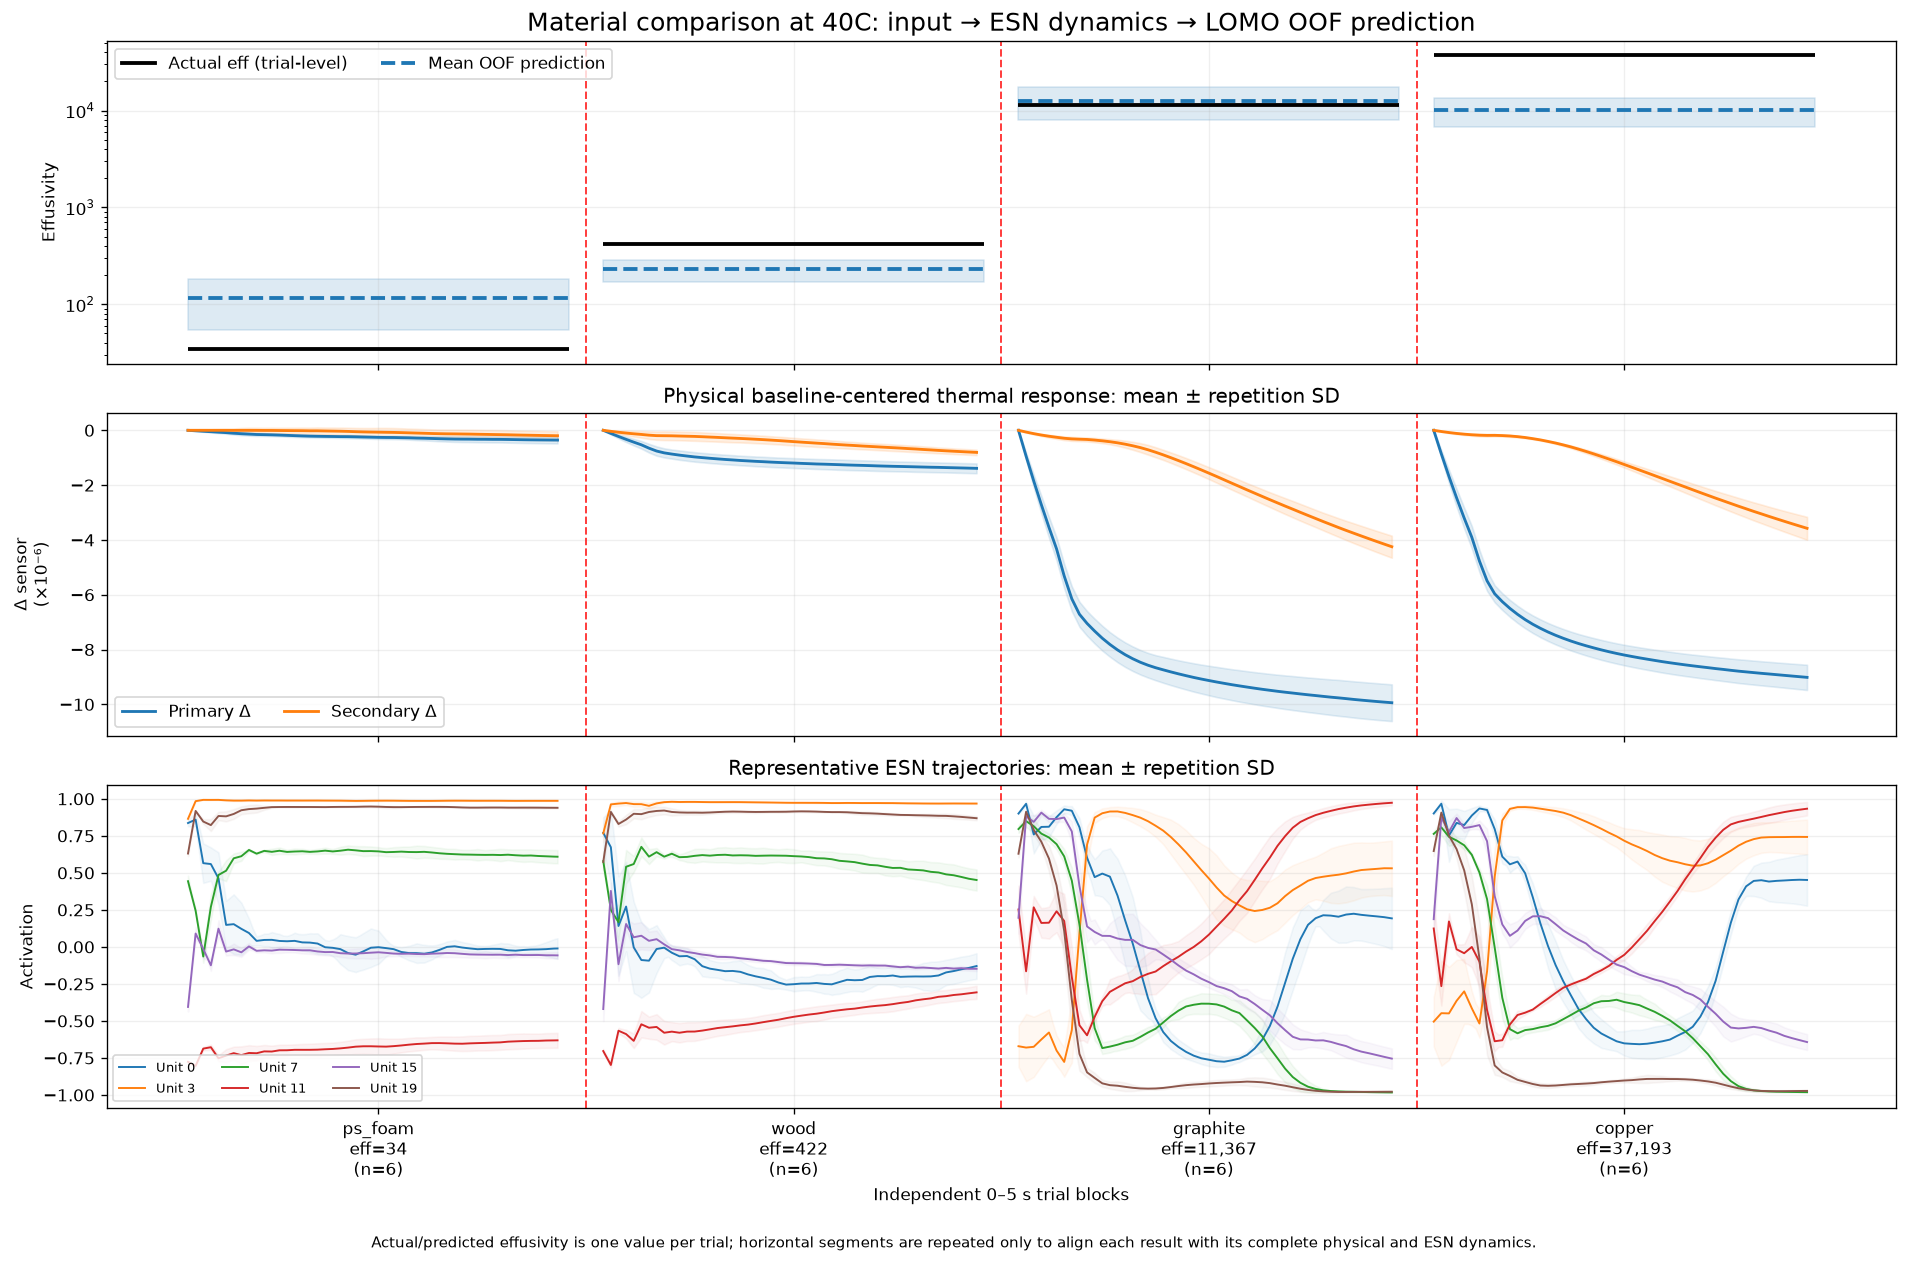

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_oof_diagnostics/material_comparison_40C.png


In [45]:
material_targets = (
    OOF[["Sample", "y_true"]].drop_duplicates().sort_values("y_true").reset_index(drop=True)
)
quantile_positions = np.unique(np.rint(np.linspace(0, len(material_targets) - 1, 4)).astype(int))
selected_materials = material_targets.iloc[quantile_positions]["Sample"].tolist()

material_blocks = []
for material in selected_materials:
    ids = OOF.loc[
        (OOF["Sample"] == material) & (OOF["Temperature"] == FIXED_TEMPERATURE),
        "trial_id",
    ].tolist()
    eff = material_targets.loc[material_targets["Sample"] == material, "y_true"].iloc[0]
    material_blocks.append(make_block(f"{material}\neff={eff:,.0f}", ids))

MATERIAL_FIGURE = plot_correspondence(
    material_blocks,
    f"Material comparison at {FIXED_TEMPERATURE}: input → ESN dynamics → LOMO OOF prediction",
    f"material_comparison_{FIXED_TEMPERATURE}.png",
)

# 7. Analysis B — all materials grouped by effusivity

**Research question:** Across all 14 materials, do physical thermal responses, collective reservoir activity and OOF predictions change systematically between the predefined low-, medium-, and high-effusivity material groups?

The groups are fixed according to the study definition:

- **Low:** PS foam, PU foam and cork
- **Medium:** gypsum, wood, PDMS and cement
- **High:** all remaining materials

Every material remains individually visible. The grouping organizes the presentation and does not replace materials with a group-average target.

,material,effusivity,effusivity_group
0,ps_foam,34.496377,Low effusivity
1,pu_foam,42.497059,Low effusivity
2,cork,136.293800,Low effusivity
3,gypsum,385.019480,Medium effusivity
4,wood,422.492603,Medium effusivity
5,pdms,460.901291,Medium effusivity
6,cement,559.642743,Medium effusivity
7,bismuth,3209.102678,High effusivity
8,titanium,7184.035927,High effusivity
9,graphite,11367.497526,High effusivity


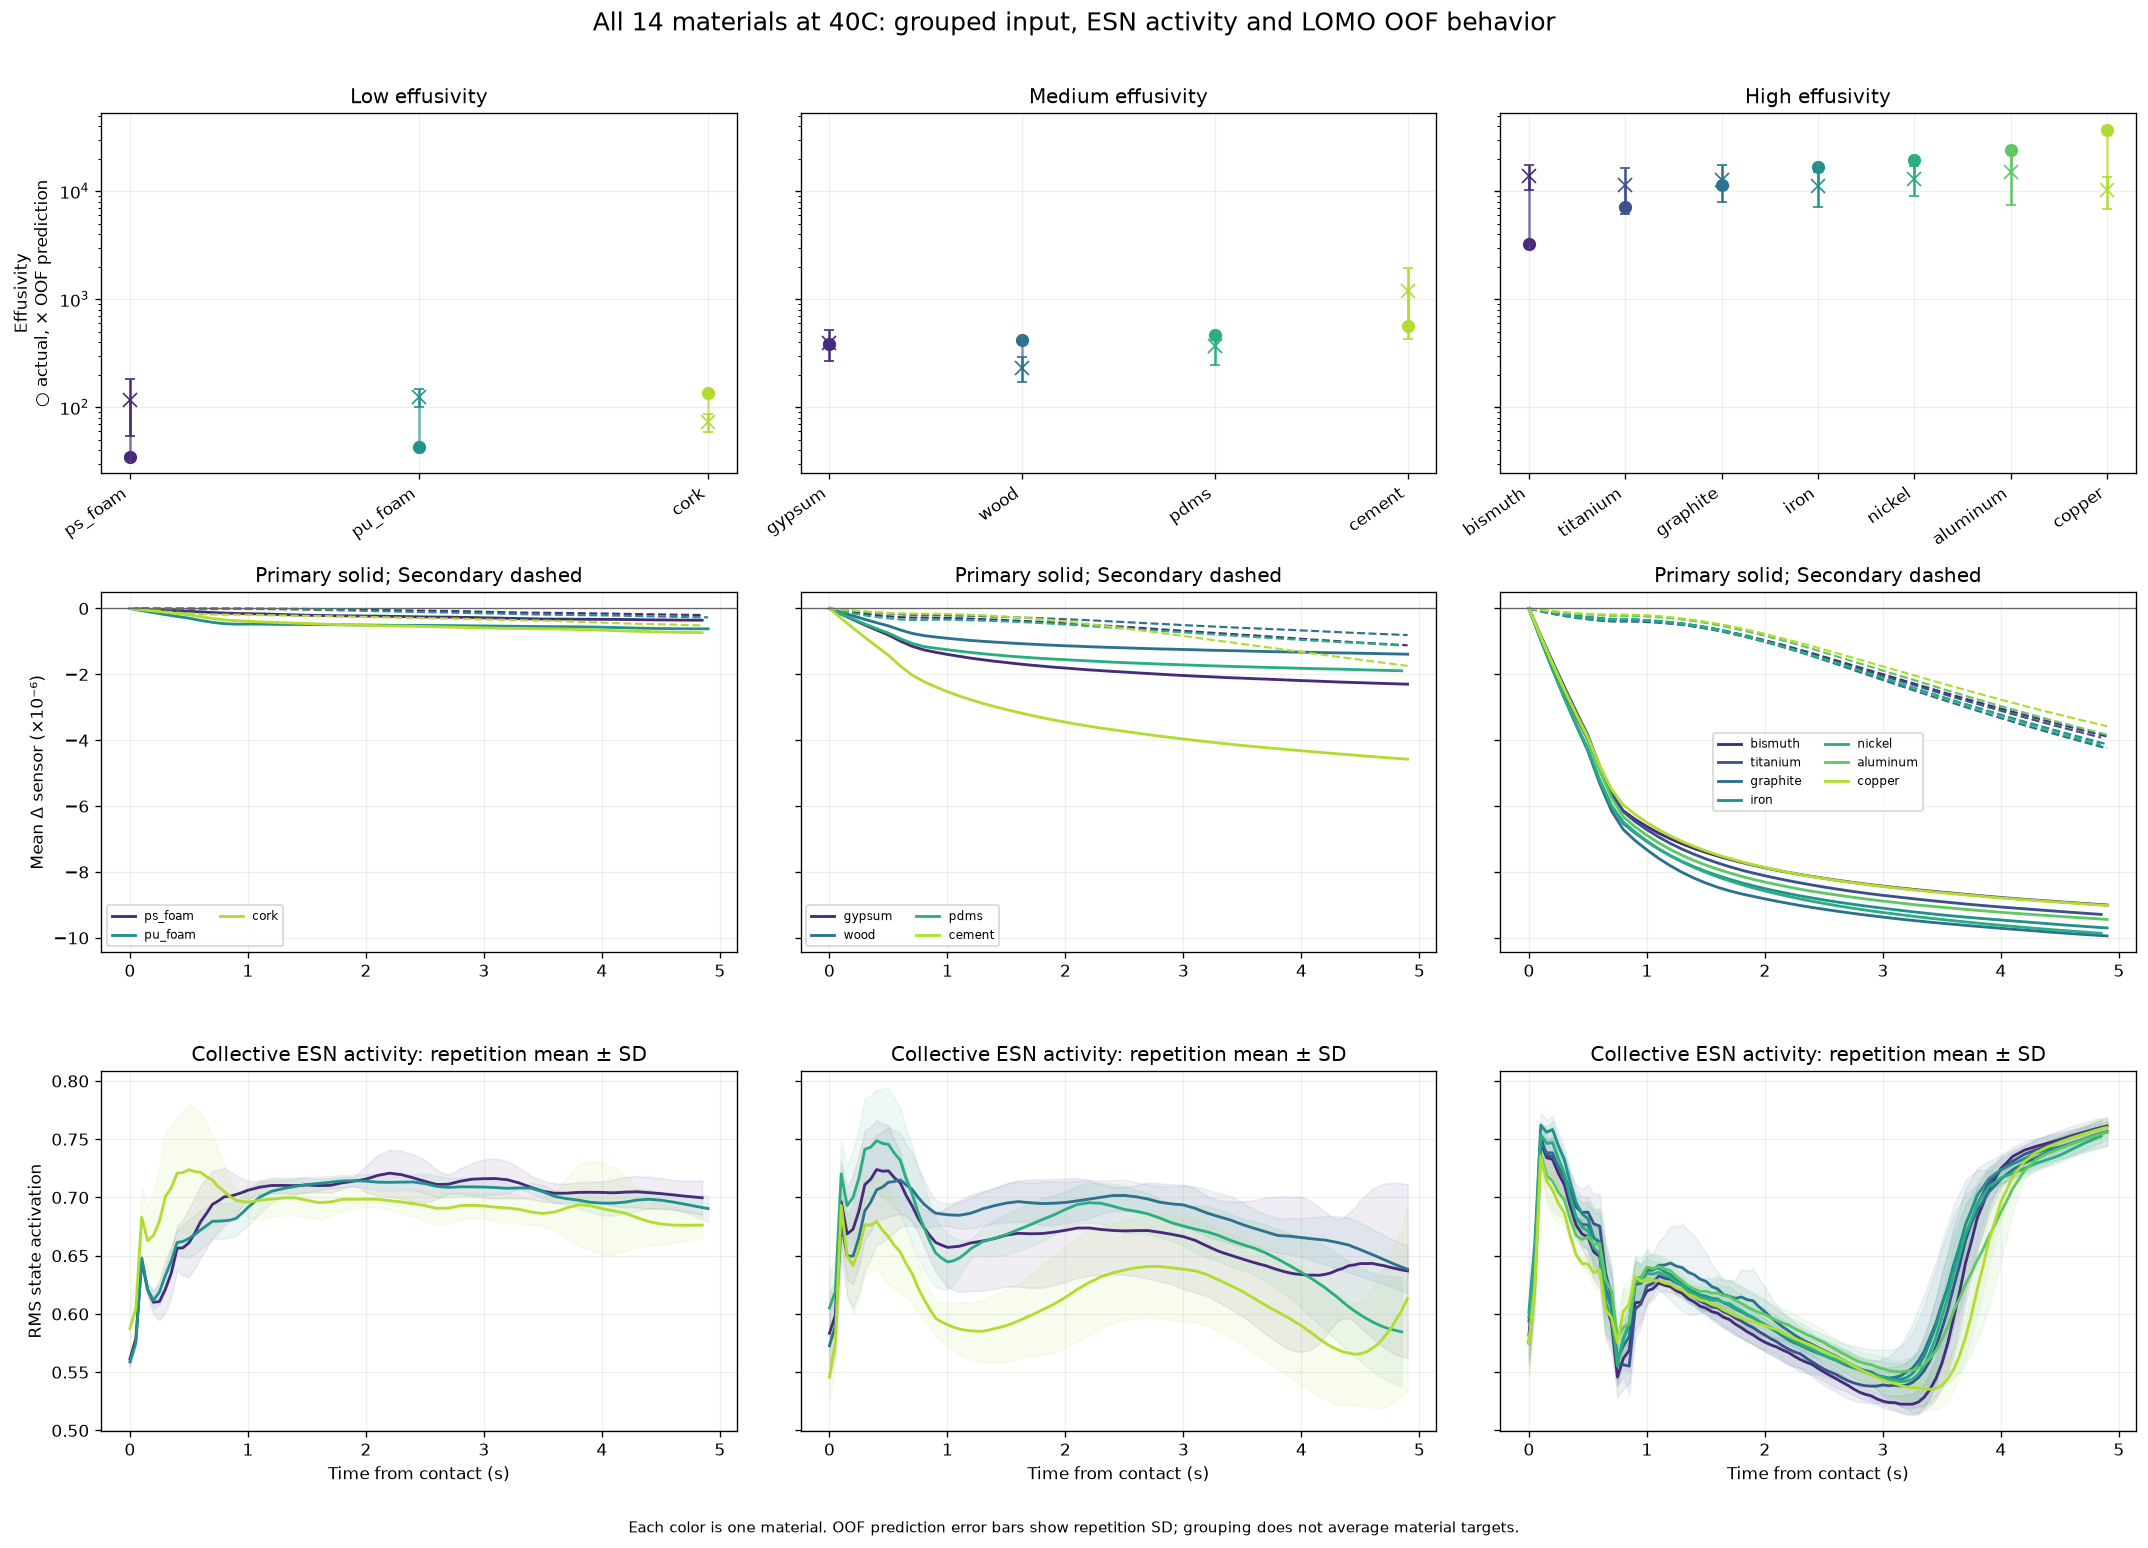

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_oof_diagnostics/all_materials_grouped_40C.png


In [46]:
# Fixed study-defined material groups. Dataset aliases use ps_foam and pu_foam.
EFFUSIVITY_GROUPS = {
    "Low effusivity": ("ps_foam", "pu_foam", "cork"),
    "Medium effusivity": ("gypsum", "wood", "pdms", "cement"),
    "High effusivity": (
        "bismuth", "graphite", "titanium", "nickel",
        "iron", "aluminum", "copper",
    ),
}
group_lookup = {
    material: group_name
    for group_name, materials in EFFUSIVITY_GROUPS.items()
    for material in materials
}

ordered_materials = material_targets.sort_values("y_true").reset_index(drop=True).copy()
ordered_materials["effusivity_group"] = ordered_materials["Sample"].map(group_lookup)
missing_group = sorted(
    ordered_materials.loc[ordered_materials["effusivity_group"].isna(), "Sample"].unique()
)
if missing_group:
    raise KeyError(f"Materials missing from EFFUSIVITY_GROUPS: {missing_group}")
unused_group_entries = sorted(set(group_lookup) - set(ordered_materials["Sample"]))
if unused_group_entries:
    warnings.warn(f"Grouped materials not present in the loaded OOF data: {unused_group_entries}")

ALL_MATERIAL_BLOCKS = {}
for row in ordered_materials.itertuples():
    ids = OOF.loc[
        (OOF["Sample"] == row.Sample)
        & (OOF["Temperature"] == FIXED_TEMPERATURE),
        "trial_id",
    ].tolist()
    ALL_MATERIAL_BLOCKS[row.Sample] = make_block(row.Sample, ids)

display(ordered_materials.rename(columns={"Sample": "material", "y_true": "effusivity"}))

group_order = ("Low effusivity", "Medium effusivity", "High effusivity")
fig, axes = plt.subplots(3, 3, figsize=(18, 13), sharey="row")

for column, group_name in enumerate(group_order):
    members = ordered_materials.loc[
        ordered_materials["effusivity_group"] == group_name, "Sample"
    ].tolist()
    palette = plt.cm.viridis(np.linspace(0.12, 0.88, len(members)))
    ax_prediction, ax_sensor, ax_activity = axes[:, column]

    # Row 1: every material's actual and mean OOF prediction.
    positions = np.arange(len(members))
    for position, material, color in zip(positions, members, palette):
        block = ALL_MATERIAL_BLOCKS[material]
        ax_prediction.plot(
            [position, position],
            [block["actual"], block["prediction_mean"]],
            color=color, alpha=0.65, linewidth=1.5,
        )
        ax_prediction.scatter(position, block["actual"], color=color, marker="o", s=48)
        ax_prediction.errorbar(
            position, block["prediction_mean"], yerr=block["prediction_sd"],
            color=color, marker="x", markersize=8, capsize=3,
        )
    ax_prediction.set_yscale("log")
    ax_prediction.set_xticks(positions, members, rotation=35, ha="right")
    ax_prediction.set_title(group_name)
    if column == 0:
        ax_prediction.set_ylabel("Effusivity\n○ actual, × OOF prediction")

    # Row 2: mean physical responses for every material at the fixed temperature.
    for material, color in zip(members, palette):
        block = ALL_MATERIAL_BLOCKS[material]
        ax_sensor.plot(
            TIME_GRID, block["raw_mean"][:, 0] * 1e6,
            color=color, linewidth=1.7, label=material,
        )
        ax_sensor.plot(
            TIME_GRID, block["raw_mean"][:, 1] * 1e6,
            color=color, linewidth=1.3, linestyle="--",
        )
    ax_sensor.axhline(0, color="0.4", linewidth=0.8)
    ax_sensor.set_title("Primary solid; Secondary dashed")
    ax_sensor.legend(fontsize=7, ncol=2, loc="best")
    if column == 0:
        ax_sensor.set_ylabel("Mean Δ sensor (×10⁻⁶)")

    # Row 3: per-repetition RMS first, followed by repetition mean ± SD.
    for material, color in zip(members, palette):
        block = ALL_MATERIAL_BLOCKS[material]
        mean = block["state_rms_mean"]
        sd = block["state_rms_sd"]
        ax_activity.plot(
            STATE_TIME_GRID, mean,
            color=color, linewidth=1.7, label=material,
        )
        ax_activity.fill_between(
            STATE_TIME_GRID, mean - sd, mean + sd,
            color=color, alpha=0.08,
        )
    ax_activity.set_title("Collective ESN activity: repetition mean ± SD")
    ax_activity.set_xlabel("Time from contact (s)")
    if column == 0:
        ax_activity.set_ylabel("RMS state activation")

fig.suptitle(
    f"All 14 materials at {FIXED_TEMPERATURE}: grouped input, ESN activity and LOMO OOF behavior",
    fontsize=15,
)
fig.text(
    0.5, 0.005,
    "Each color is one material. OOF prediction error bars show repetition SD; grouping does not average material targets.",
    ha="center", fontsize=9,
)
fig.tight_layout(rect=(0, 0.025, 1, 0.97))
ALL_MATERIALS_FIGURE = DIAGNOSTIC_DIR / f"all_materials_grouped_{FIXED_TEMPERATURE}.png"
fig.savefig(ALL_MATERIALS_FIGURE, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", ALL_MATERIALS_FIGURE)

# 8. Analysis C — one material across four temperatures

**Research question:** How strongly does operating temperature change the same material's inputs, reservoir response and OOF effusivity prediction?

The true material effusivity remains constant. Temperature-dependent prediction drift indicates remaining temperature sensitivity.

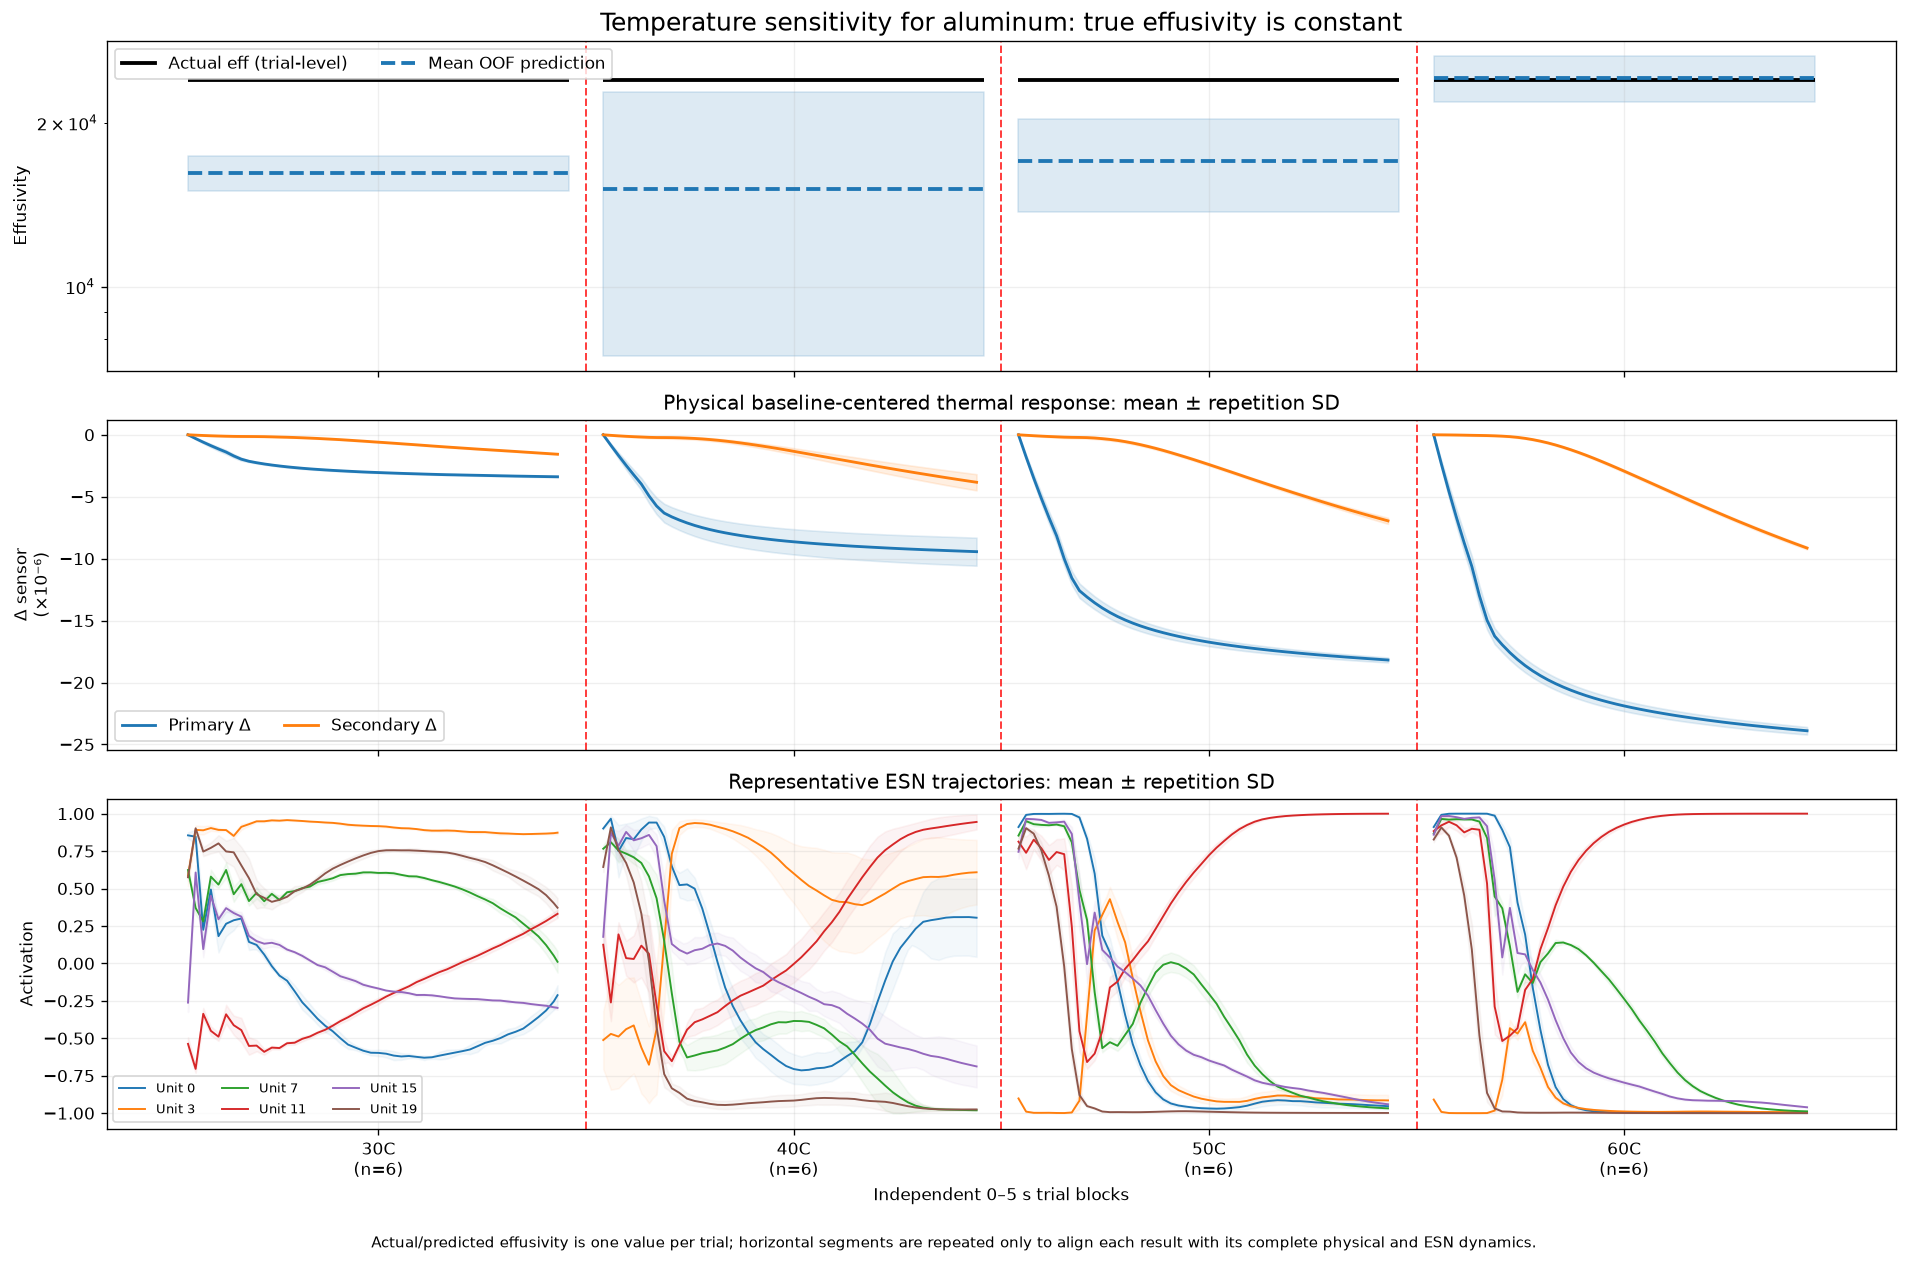

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_oof_diagnostics/temperature_comparison_aluminum.png


In [47]:
if TEMPERATURE_COMPARISON_MATERIAL not in OOF["Sample"].unique():
    raise KeyError(TEMPERATURE_COMPARISON_MATERIAL)

temperature_blocks = []
for temperature in TEMPERATURE_FOLDERS:
    ids = OOF.loc[
        (OOF["Sample"] == TEMPERATURE_COMPARISON_MATERIAL)
        & (OOF["Temperature"] == temperature),
        "trial_id",
    ].tolist()
    temperature_blocks.append(make_block(temperature, ids))

TEMPERATURE_FIGURE = plot_correspondence(
    temperature_blocks,
    f"Temperature sensitivity for {TEMPERATURE_COMPARISON_MATERIAL}: true effusivity is constant",
    f"temperature_comparison_{TEMPERATURE_COMPARISON_MATERIAL}.png",
)

# 9. Analysis D — six nominally identical repetitions

**Research question:** Under the same material and temperature, are the physical inputs, ESN trajectories and OOF predictions repeatable?

Each block contains one trial, so no variability band is drawn inside a block. Differences between blocks directly show repetition-to-repetition variation.

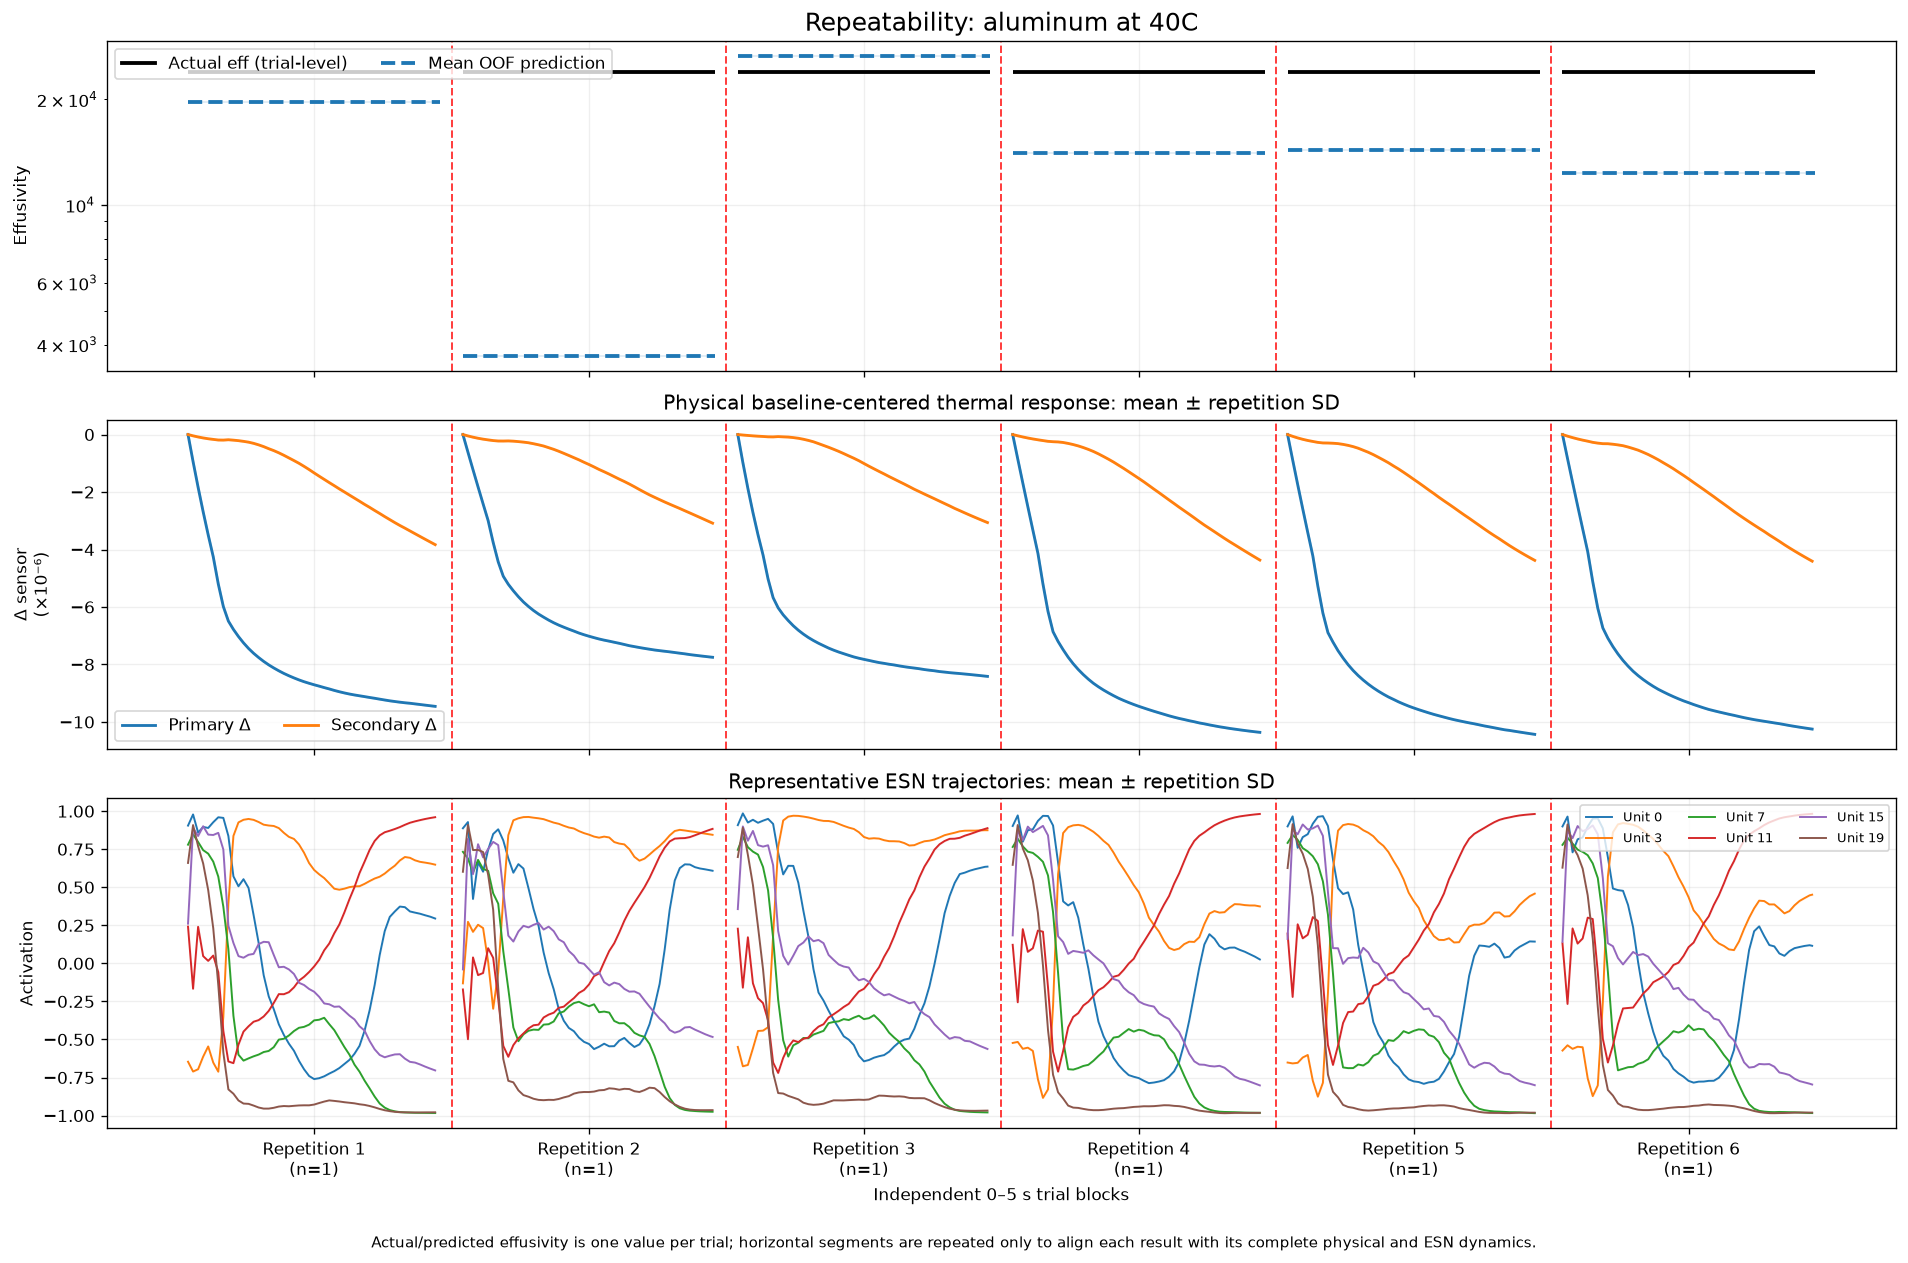

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_oof_diagnostics/repetition_comparison_aluminum_40C.png


In [48]:
repetition_rows = OOF[
    (OOF["Sample"] == REPETITION_COMPARISON_MATERIAL)
    & (OOF["Temperature"] == REPETITION_COMPARISON_TEMPERATURE)
].sort_values("Trial")

repetition_blocks = [
    make_block(f"Repetition {int(row.Trial)}", [row.trial_id])
    for row in repetition_rows.itertuples()
]

REPETITION_FIGURE = plot_correspondence(
    repetition_blocks,
    f"Repeatability: {REPETITION_COMPARISON_MATERIAL} at {REPETITION_COMPARISON_TEMPERATURE}",
    f"repetition_comparison_{REPETITION_COMPARISON_MATERIAL}_{REPETITION_COMPARISON_TEMPERATURE}.png",
)

# 10. Quantify interpretable input–target relationships

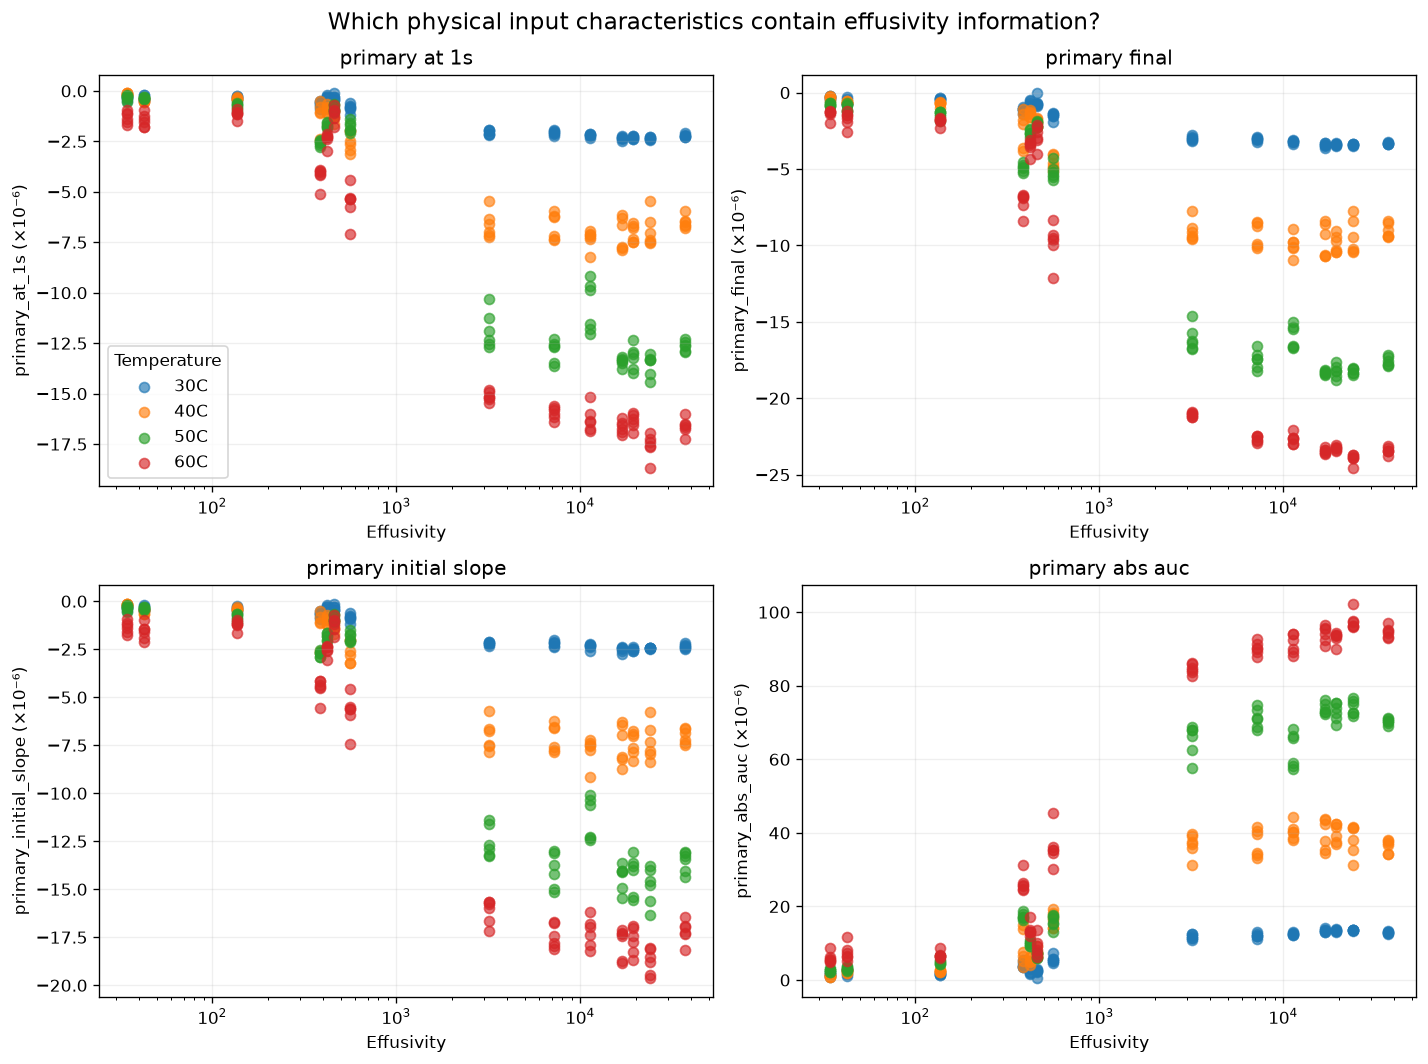

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_oof_diagnostics/input_features_vs_effusivity.png


Temperature,30C,40C,50C,60C
feature,,,,
primary_abs_auc,0.948091,0.938307,0.946488,0.950677
primary_at_1s,-0.938622,-0.934981,-0.938195,-0.944293
primary_final,-0.952152,-0.938356,-0.952498,-0.953376
primary_initial_slope,-0.936795,-0.933448,-0.937121,-0.940378


In [49]:
def trial_input_summaries(trial_id):
    trial = aligned_trials[trial_id]
    time = trial["time_from_contact"].to_numpy(float)
    inputs = raw_esn_input(trial)
    primary, secondary = inputs[:, 0], inputs[:, 1]
    early = time <= min(1.0, ANALYSIS_WINDOW[1])
    return {
        "trial_id": trial_id,
        "primary_at_1s": float(np.interp(1.0, time, primary)),
        "secondary_at_1s": float(np.interp(1.0, time, secondary)),
        "primary_final": float(primary[-1]),
        "secondary_final": float(secondary[-1]),
        "primary_initial_slope": float(np.polyfit(time[early], primary[early], 1)[0]),
        "secondary_initial_slope": float(np.polyfit(time[early], secondary[early], 1)[0]),
        "primary_abs_auc": float(np.trapezoid(np.abs(primary), time)),
        "secondary_abs_auc": float(np.trapezoid(np.abs(secondary), time)),
    }


INPUT_SUMMARIES = pd.DataFrame([trial_input_summaries(x) for x in common_ids]).merge(
    OOF[["trial_id", "Sample", "Temperature", "Temperature_C", "Trial", "y_true", "y_pred"]],
    on="trial_id", how="inner",
)

features = [
    "primary_at_1s", "primary_final", "primary_initial_slope", "primary_abs_auc"
]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for axis, feature in zip(axes.ravel(), features):
    for temperature, part in INPUT_SUMMARIES.groupby("Temperature", sort=True):
        axis.scatter(part["y_true"], part[feature] * 1e6, alpha=0.65, label=temperature)
    axis.set_xscale("log")
    axis.set(xlabel="Effusivity", ylabel=f"{feature} (×10⁻⁶)", title=feature.replace("_", " "))
axes[0, 0].legend(title="Temperature")
fig.suptitle("Which physical input characteristics contain effusivity information?", fontsize=14)
fig.tight_layout()
INPUT_FEATURE_FIGURE = DIAGNOSTIC_DIR / "input_features_vs_effusivity.png"
fig.savefig(INPUT_FEATURE_FIGURE, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", INPUT_FEATURE_FIGURE)

correlation_rows = []
for temperature, part in INPUT_SUMMARIES.groupby("Temperature", sort=True):
    for feature in features:
        correlation_rows.append({
            "Temperature": temperature,
            "feature": feature,
            "pearson_r_with_log_eff": float(np.corrcoef(np.log1p(part["y_true"]), part[feature])[0, 1]),
        })
CORRELATIONS = pd.DataFrame(correlation_rows)
display(CORRELATIONS.pivot(index="feature", columns="Temperature", values="pearson_r_with_log_eff"))

# 11. OOF residual diagnosis by material and temperature

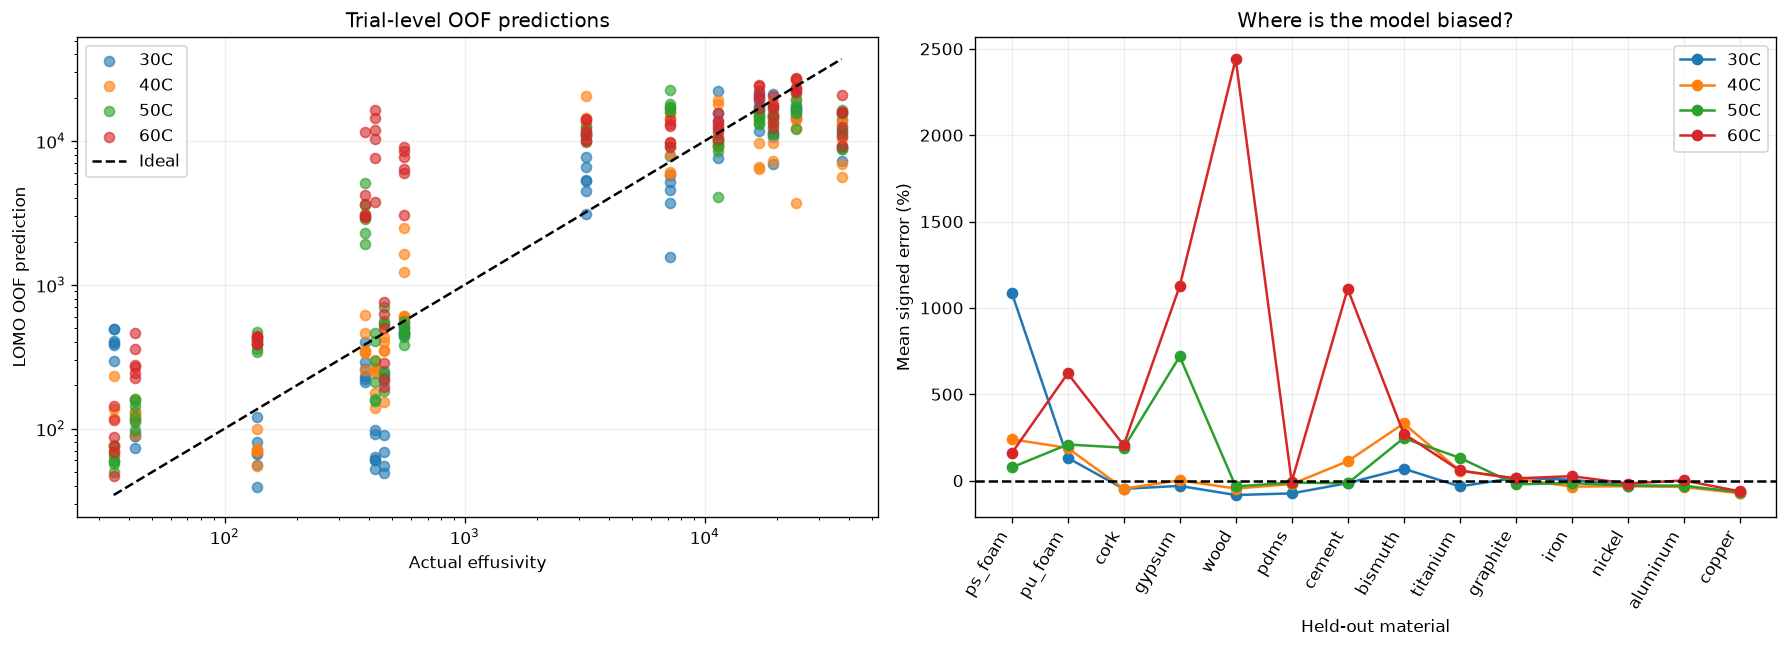

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_oof_diagnostics/oof_prediction_and_residual_diagnosis.png


,Sample,actual_eff,mean_prediction,prediction_sd,mean_signed_error_pct,median_absolute_error_pct,n_trials
10,ps_foam,34.496377,169.341856,151.404715,390.897517,136.935584,24
11,pu_foam,42.497059,164.741711,96.105797,287.654382,202.087691,24
4,cork,136.293800,239.257183,173.089736,75.545170,111.580327,24
6,gypsum,385.019480,2134.033759,2539.193789,454.266438,229.643960,24
13,wood,422.492603,2829.803982,5130.974877,569.787816,71.910470,24
9,pdms,460.901291,332.455777,207.182789,-27.868335,48.341739,24
2,cement,559.642743,2228.820687,2903.293683,298.257766,19.412188,24
1,bismuth,3209.102678,10579.507043,3800.213991,229.671815,244.307843,24
12,titanium,7184.035927,11056.885919,5530.240432,53.909112,62.664339,24
5,graphite,11367.497526,11917.598811,4056.716962,4.839247,18.875832,24


In [50]:
OOF_DIAGNOSTICS = OOF.copy()
OOF_DIAGNOSTICS["residual"] = OOF_DIAGNOSTICS["y_pred"] - OOF_DIAGNOSTICS["y_true"]
OOF_DIAGNOSTICS["relative_error_pct"] = 100 * OOF_DIAGNOSTICS["residual"] / OOF_DIAGNOSTICS["y_true"]

material_order = (
    OOF_DIAGNOSTICS.groupby("Sample")["y_true"].first().sort_values().index.tolist()
)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for temperature, part in OOF_DIAGNOSTICS.groupby("Temperature", sort=True):
    axes[0].scatter(part["y_true"], part["y_pred"], alpha=0.62, label=temperature)
low = min(OOF_DIAGNOSTICS["y_true"].min(), OOF_DIAGNOSTICS["y_pred"].min())
high = max(OOF_DIAGNOSTICS["y_true"].max(), OOF_DIAGNOSTICS["y_pred"].max())
axes[0].plot([low, high], [low, high], "k--", label="Ideal")
axes[0].set(xscale="log", yscale="log", xlabel="Actual effusivity", ylabel="LOMO OOF prediction", title="Trial-level OOF predictions")
axes[0].legend()

positions = np.arange(len(material_order))
for temperature_index, temperature in enumerate(TEMPERATURE_FOLDERS):
    means = OOF_DIAGNOSTICS[OOF_DIAGNOSTICS["Temperature"] == temperature].groupby("Sample")["relative_error_pct"].mean()
    axes[1].plot(positions, [means.get(x, np.nan) for x in material_order], marker="o", label=temperature)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xticks(positions, material_order, rotation=60, ha="right")
axes[1].set(xlabel="Held-out material", ylabel="Mean signed error (%)", title="Where is the model biased?")
axes[1].legend()

fig.tight_layout()
OOF_DIAGNOSTIC_FIGURE = DIAGNOSTIC_DIR / "oof_prediction_and_residual_diagnosis.png"
fig.savefig(OOF_DIAGNOSTIC_FIGURE, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", OOF_DIAGNOSTIC_FIGURE)

MATERIAL_ERROR_TABLE = OOF_DIAGNOSTICS.groupby("Sample", as_index=False).agg(
    actual_eff=("y_true", "mean"),
    mean_prediction=("y_pred", "mean"),
    prediction_sd=("y_pred", "std"),
    mean_signed_error_pct=("relative_error_pct", "mean"),
    median_absolute_error_pct=("relative_error_pct", lambda x: float(np.median(np.abs(x)))),
    n_trials=("trial_id", "size"),
).sort_values("actual_eff")
display(MATERIAL_ERROR_TABLE)

# 12. Complete all-material analysis framework

The following sections replace conclusions drawn from four examples with analyses covering all **14 materials × 4 temperatures × 6 repetitions = 336 OOF trials**. The detailed trajectory plots remain useful as case studies, while these figures establish whether their patterns generalize.

## 12.1 Prediction-error heatmaps

**Research question:** Which material–temperature combinations are systematically overpredicted, underpredicted, inaccurate or variable across repetitions?

In [ ]:
def annotated_heatmap(
    axis, table, title, colorbar_label, cmap="viridis", center=None,
    value_format=".0f", robust=False,
):
    values = table.to_numpy(float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        raise ValueError(f"No finite values for {title}")
    if center is not None:
        limit = np.nanpercentile(np.abs(finite - center), 95) if robust else np.max(np.abs(finite - center))
        limit = max(float(limit), np.finfo(float).eps)
        norm = TwoSlopeNorm(vmin=center - limit, vcenter=center, vmax=center + limit)
        image = axis.imshow(values, aspect="auto", cmap=cmap, norm=norm)
    else:
        vmax = np.nanpercentile(finite, 95) if robust else np.max(finite)
        image = axis.imshow(values, aspect="auto", cmap=cmap, vmin=np.min(finite), vmax=vmax)
    axis.set_xticks(np.arange(table.shape[1]), table.columns)
    axis.set_yticks(np.arange(table.shape[0]), table.index)
    axis.set_title(title)
    for row in range(table.shape[0]):
        for column in range(table.shape[1]):
            value = values[row, column]
            if np.isfinite(value):
                axis.text(column, row, format(value, value_format), ha="center", va="center", fontsize=7)
    colorbar = axis.figure.colorbar(image, ax=axis, fraction=0.046, pad=0.03)
    colorbar.set_label(colorbar_label)
    return image


def save_figure(fig, filename):
    output = DIAGNOSTIC_DIR / filename
    fig.savefig(output, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", output)
    return output


CONDITION_SUMMARY = (
    OOF_DIAGNOSTICS.groupby(["Sample", "Temperature"], as_index=False)
    .agg(
        actual_eff=("y_true", "first"),
        mean_prediction=("y_pred", "mean"),
        prediction_sd=("y_pred", "std"),
        n=("trial_id", "size"),
    )
)
CONDITION_SUMMARY["signed_error_pct"] = 100 * (
    CONDITION_SUMMARY["mean_prediction"] - CONDITION_SUMMARY["actual_eff"]
) / CONDITION_SUMMARY["actual_eff"]
CONDITION_SUMMARY["absolute_error_pct"] = np.abs(CONDITION_SUMMARY["signed_error_pct"])
CONDITION_SUMMARY["prediction_relative_sd_pct"] = (
    100 * CONDITION_SUMMARY["prediction_sd"] / CONDITION_SUMMARY["actual_eff"]
)
CONDITION_SUMMARY["effusivity_group"] = CONDITION_SUMMARY["Sample"].map(group_lookup)


def condition_matrix(column):
    return (
        CONDITION_SUMMARY.pivot(index="Sample", columns="Temperature", values=column)
        .reindex(index=material_order, columns=TEMPERATURE_FOLDERS)
    )


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)
annotated_heatmap(
    axes[0], condition_matrix("signed_error_pct"),
    "Mean signed OOF error", "Signed error (%)",
    cmap="RdBu_r", center=0.0, robust=True,
)
annotated_heatmap(
    axes[1], condition_matrix("absolute_error_pct"),
    "Mean absolute OOF error", "Absolute error (%)",
    cmap="magma", robust=True,
)
annotated_heatmap(
    axes[2], condition_matrix("prediction_relative_sd_pct"),
    "OOF prediction variability", "Prediction SD / actual (%)",
    cmap="cividis", robust=True,
)
fig.suptitle("Complete 14-material × 4-temperature OOF diagnosis (six repetitions per cell)", fontsize=15)
ERROR_HEATMAP_FIGURE = save_figure(fig, "all_material_temperature_error_heatmaps.png")

print("Color limits use the 95th percentile so extreme low-effusivity percentage errors do not hide the remaining structure.")
display(CONDITION_SUMMARY.sort_values("absolute_error_pct", ascending=False).head(12))


## 12.2 Trial-level and material–temperature prediction views

The left panel retains all 336 OOF predictions. The right panel reduces them to 56 condition means while preserving repetition SD.

In [ ]:
temperature_colors = dict(zip(TEMPERATURE_FOLDERS, plt.cm.plasma(np.linspace(0.12, 0.88, 4))))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for temperature in TEMPERATURE_FOLDERS:
    trials = OOF_DIAGNOSTICS[OOF_DIAGNOSTICS["Temperature"] == temperature]
    axes[0].scatter(
        trials["y_true"], trials["y_pred"], s=24, alpha=0.45,
        color=temperature_colors[temperature], label=temperature,
    )
    means = CONDITION_SUMMARY[CONDITION_SUMMARY["Temperature"] == temperature]
    axes[1].errorbar(
        means["actual_eff"], means["mean_prediction"], yerr=means["prediction_sd"],
        fmt="o", markersize=5, capsize=2, alpha=0.85,
        color=temperature_colors[temperature], label=temperature,
    )

positive = np.concatenate([OOF_DIAGNOSTICS["y_true"].to_numpy(), OOF_DIAGNOSTICS["y_pred"].to_numpy()])
low, high = positive[positive > 0].min(), positive.max()
for axis, title in zip(
    axes,
    ("All 336 trial-level OOF predictions", "56 material–temperature means ± repetition SD"),
):
    axis.plot([low, high], [low, high], "k--", linewidth=1.3, label="Ideal")
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Actual effusivity")
    axis.set_ylabel("LOMO OOF prediction")
    axis.set_title(title)
    axis.legend()

fig.suptitle("Trial variation versus systematic material–temperature bias", fontsize=14)
fig.tight_layout()
ALL_OOF_FIGURE = save_figure(fig, "all_oof_trial_and_condition_predictions.png")


## 12.3 Temperature-dependent error by effusivity group

**Research question:** Is any improvement at 50–60 °C consistent across materials, or driven by only a few examples? Thin colored lines are individual materials; the thick black line is the group median.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True)
temperature_positions = np.arange(len(TEMPERATURE_FOLDERS))

for column, group_name in enumerate(group_order):
    group_data = CONDITION_SUMMARY[CONDITION_SUMMARY["effusivity_group"] == group_name]
    members = [m for m in material_order if group_lookup[m] == group_name]
    palette = plt.cm.viridis(np.linspace(0.12, 0.88, len(members)))
    for material, color in zip(members, palette):
        part = group_data[group_data["Sample"] == material].set_index("Temperature").reindex(TEMPERATURE_FOLDERS)
        axes[0, column].plot(
            temperature_positions, part["signed_error_pct"], marker="o",
            color=color, linewidth=1.3, label=material,
        )
        axes[1, column].plot(
            temperature_positions, part["absolute_error_pct"], marker="o",
            color=color, linewidth=1.3, label=material,
        )

    medians = group_data.groupby("Temperature")[["signed_error_pct", "absolute_error_pct"]].median().reindex(TEMPERATURE_FOLDERS)
    axes[0, column].plot(temperature_positions, medians["signed_error_pct"], "k-o", linewidth=3, label="Group median")
    axes[1, column].plot(temperature_positions, medians["absolute_error_pct"], "k-o", linewidth=3, label="Group median")
    axes[0, column].axhline(0, color="0.4", linestyle="--", linewidth=0.8)
    axes[0, column].set_title(group_name)
    axes[1, column].set_xticks(temperature_positions, TEMPERATURE_FOLDERS)
    axes[0, column].legend(fontsize=7, ncol=2)

axes[0, 0].set_ylabel("Mean signed error (%)")
axes[1, 0].set_ylabel("Mean absolute error (%)")
for axis in axes[1]:
    axis.set_xlabel("Operating temperature")
fig.suptitle("Does prediction accuracy improve with temperature across all effusivity groups?", fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97))
TEMPERATURE_ERROR_FIGURE = save_figure(fig, "temperature_error_profiles_by_effusivity_group.png")


## 12.4 Physical and ESN repeatability across all conditions

Physical repeatability is the coefficient of variation of response AUC across six repetitions. ESN repeatability is the mean standardized distance of each trial's full summarized reservoir vector from its material–temperature centroid. Lower values indicate better repeatability.

In [ ]:
# Physical repeatability uses positive response-AUC summaries, making CV interpretable.
physical_condition = (
    INPUT_SUMMARIES.groupby(["Sample", "Temperature"], as_index=False)
    .agg(
        primary_auc_mean=("primary_abs_auc", "mean"),
        primary_auc_sd=("primary_abs_auc", "std"),
        secondary_auc_mean=("secondary_abs_auc", "mean"),
        secondary_auc_sd=("secondary_abs_auc", "std"),
    )
)
epsilon = np.finfo(float).eps
physical_condition["primary_auc_cv_pct"] = 100 * physical_condition["primary_auc_sd"] / (np.abs(physical_condition["primary_auc_mean"]) + epsilon)
physical_condition["secondary_auc_cv_pct"] = 100 * physical_condition["secondary_auc_sd"] / (np.abs(physical_condition["secondary_auc_mean"]) + epsilon)


def state_summary_vector(trial_id):
    states = trial_diagnostics(trial_id)["states"]
    time = STATE_TIME_GRID
    values = []
    for unit in range(states.shape[1]):
        trajectory = states[:, unit]
        finite = np.isfinite(trajectory)
        trajectory = trajectory[finite]
        unit_time = time[finite]
        if len(trajectory) < 2:
            raise ValueError(f"Insufficient ESN trajectory for {trial_id}, unit {unit}")
        values.extend([
            np.mean(trajectory), np.std(trajectory), np.ptp(trajectory),
            trajectory[-1] - trajectory[0],
            np.polyfit(unit_time, trajectory, 1)[0],
            np.trapezoid(np.abs(trajectory), unit_time),
        ])
    return values


print("Building all-trial ESN summary matrix once; reconstructed trials are cached...")
ESN_MATRIX = np.asarray([state_summary_vector(trial_id) for trial_id in common_ids], float)
if not np.all(np.isfinite(ESN_MATRIX)):
    raise ValueError("Non-finite values were found in the all-trial ESN summary matrix.")
ESN_Z = StandardScaler().fit_transform(ESN_MATRIX)
ESN_SUMMARIES = OOF.set_index("trial_id").loc[common_ids, [
    "Sample", "Temperature", "Temperature_C", "Trial", "y_true", "y_pred"
]].reset_index()
ESN_SUMMARIES["esn_vector"] = list(ESN_Z)

esn_repeatability_rows = []
for (material, temperature), part in ESN_SUMMARIES.groupby(["Sample", "Temperature"]):
    matrix = np.vstack(part["esn_vector"])
    center = matrix.mean(axis=0)
    distances = np.linalg.norm(matrix - center, axis=1) / np.sqrt(matrix.shape[1])
    esn_repeatability_rows.append({
        "Sample": material,
        "Temperature": temperature,
        "esn_repeatability_distance": float(distances.mean()),
    })
ESN_REPEATABILITY = pd.DataFrame(esn_repeatability_rows)


def repeatability_matrix(frame, column):
    return frame.pivot(index="Sample", columns="Temperature", values=column).reindex(
        index=material_order, columns=TEMPERATURE_FOLDERS
    )


fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)
annotated_heatmap(
    axes[0], repeatability_matrix(physical_condition, "primary_auc_cv_pct"),
    "Primary-response repeatability", "AUC CV (%)", cmap="magma", robust=True,
)
annotated_heatmap(
    axes[1], repeatability_matrix(physical_condition, "secondary_auc_cv_pct"),
    "Secondary-response repeatability", "AUC CV (%)", cmap="magma", robust=True,
)
annotated_heatmap(
    axes[2], repeatability_matrix(ESN_REPEATABILITY, "esn_repeatability_distance"),
    "Summarized ESN repeatability", "Mean standardized distance", cmap="magma", value_format=".2f", robust=True,
)
fig.suptitle("Where are the six repetitions physically or representationally inconsistent?", fontsize=15)
REPEATABILITY_FIGURE = save_figure(fig, "physical_and_esn_repeatability_heatmaps.png")


## 12.5 Material separability in thermal, ESN and combined feature spaces

Each cell is the standardized Euclidean distance between two material centroids. Dark/small values indicate materials that the regressor may find difficult to distinguish. Clustering only reorders the axes; it does not change the distances.

In [ ]:
# Compare material centroids in standardized thermal, ESN and combined feature spaces.
thermal_columns = [
    "primary_at_1s", "secondary_at_1s", "primary_final", "secondary_final",
    "primary_initial_slope", "secondary_initial_slope",
    "primary_abs_auc", "secondary_abs_auc",
]
thermal_by_id = INPUT_SUMMARIES.set_index("trial_id").loc[common_ids, thermal_columns]
thermal_z = StandardScaler().fit_transform(thermal_by_id)
combined_z = np.column_stack([thermal_z, ESN_Z])
metadata_by_id = OOF.set_index("trial_id").loc[common_ids, ["Sample", "Temperature"]].reset_index()


def material_distance_matrix(feature_matrix):
    frame = metadata_by_id.copy()
    frame["vector"] = list(feature_matrix)
    materials = material_order
    centroids = np.vstack([
        np.vstack(frame.loc[frame["Sample"] == material, "vector"]).mean(axis=0)
        for material in materials
    ])
    distances = squareform(pdist(centroids, metric="euclidean")) / np.sqrt(centroids.shape[1])
    if len(materials) > 2:
        order = leaves_list(linkage(centroids, method="average", metric="euclidean"))
    else:
        order = np.arange(len(materials))
    ordered = [materials[index] for index in order]
    table = pd.DataFrame(distances, index=materials, columns=materials).loc[ordered, ordered]
    return table, pd.DataFrame(distances, index=materials, columns=materials)


THERMAL_DISTANCE_CLUSTERED, THERMAL_DISTANCE = material_distance_matrix(thermal_z)
ESN_DISTANCE_CLUSTERED, ESN_DISTANCE = material_distance_matrix(ESN_Z)
COMBINED_DISTANCE_CLUSTERED, COMBINED_DISTANCE = material_distance_matrix(combined_z)

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5), constrained_layout=True)
for axis, table, title in zip(
    axes,
    (THERMAL_DISTANCE_CLUSTERED, ESN_DISTANCE_CLUSTERED, COMBINED_DISTANCE_CLUSTERED),
    ("Manual thermal features", "Summarized ESN features", "Combined thermal + ESN"),
):
    image = axis.imshow(table, cmap="viridis", aspect="equal")
    axis.set_xticks(np.arange(len(table)), table.columns, rotation=70, ha="right", fontsize=7)
    axis.set_yticks(np.arange(len(table)), table.index, fontsize=7)
    axis.set_title(title)
    axis.figure.colorbar(image, ax=axis, fraction=0.046, pad=0.03, label="Standardized centroid distance")
fig.suptitle("Which materials occupy similar regions of feature space?", fontsize=15)
SEPARABILITY_FIGURE = save_figure(fig, "thermal_esn_combined_material_separability.png")

# Nearest material in the combined representation.
nearest_rows = []
for material in material_order:
    distances = COMBINED_DISTANCE.loc[material].drop(material)
    nearest_rows.append({
        "material": material,
        "nearest_material": distances.idxmin(),
        "combined_distance": float(distances.min()),
    })
NEAREST_MATERIALS = pd.DataFrame(nearest_rows)
display(NEAREST_MATERIALS)


## 12.6 Connect data characteristics to prediction error

These plots test whether error is associated with weak signals, poor repetition repeatability, unstable ESN representations or proximity to another material. Spearman correlation describes monotonic association and should not be interpreted as proof of causation.

In [ ]:
EXPLANATION_TABLE = (
    CONDITION_SUMMARY
    .merge(physical_condition, on=["Sample", "Temperature"], how="left")
    .merge(ESN_REPEATABILITY, on=["Sample", "Temperature"], how="left")
    .merge(NEAREST_MATERIALS[["material", "combined_distance"]], left_on="Sample", right_on="material", how="left")
)
EXPLANATION_TABLE["primary_response_magnitude"] = EXPLANATION_TABLE["primary_auc_mean"] * 1e6

relationships = [
    ("primary_response_magnitude", "Primary response AUC (×10⁻⁶)"),
    ("primary_auc_cv_pct", "Primary-response CV (%)"),
    ("esn_repeatability_distance", "ESN repetition distance"),
    ("combined_distance", "Nearest-material combined distance"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
relationship_rows = []

for axis, (column, label) in zip(axes.ravel(), relationships):
    for temperature in TEMPERATURE_FOLDERS:
        part = EXPLANATION_TABLE[EXPLANATION_TABLE["Temperature"] == temperature]
        axis.scatter(
            part[column], part["absolute_error_pct"],
            color=temperature_colors[temperature], alpha=0.75, label=temperature,
        )
    valid = EXPLANATION_TABLE[[column, "absolute_error_pct"]].dropna()
    rho, p_value = spearmanr(valid[column], valid["absolute_error_pct"])
    relationship_rows.append({"explanatory_quantity": column, "spearman_rho": rho, "p_value": p_value})
    axis.set_xlabel(label)
    axis.set_ylabel("Absolute OOF error (%)")
    axis.set_title(f"ρ={rho:.2f}, p={p_value:.3g}")

axes[0, 0].legend(title="Temperature")
fig.suptitle("Do signal strength, repeatability and material separation explain OOF error?", fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97))
ERROR_EXPLANATION_FIGURE = save_figure(fig, "oof_error_explanation_relationships.png")

RELATIONSHIP_STATISTICS = pd.DataFrame(relationship_rows)
display(RELATIONSHIP_STATISTICS)
display(EXPLANATION_TABLE.sort_values("absolute_error_pct", ascending=False).head(15))


# 13. Interpretation checklist

Use the figures to answer these questions in order:

1. **Material signal:** At fixed temperature, do higher-effusivity materials show systematically different response magnitude, slope or shape?
2. **Temperature sensitivity:** For one material, how much do the input and reservoir dynamics shift with temperature? Does the OOF estimate shift even though true effusivity is constant?
3. **Repeatability:** Do nominally identical repetitions generate similar input curves, reservoir trajectories and predictions?
4. **Reservoir transformation:** Do distinct input dynamics remain distinct in the representative ESN trajectories, or do many units saturate into nearly identical patterns?
5. **Prediction correspondence:** Do prediction errors become larger precisely where material trajectories overlap or become noisy?
6. **Bias:** Are extreme-effusivity materials consistently pulled toward the middle of the target range?

Avoid claiming that one reservoir unit has a direct physical meaning. Interpret the reservoir as a distributed nonlinear representation and connect its patterns back to measurable sensor behavior.

In [51]:
print("Diagnostic outputs:")
for path in sorted(DIAGNOSTIC_DIR.glob("*.png")):
    print(" -", path.name)

Diagnostic outputs:
 - all_materials_grouped_40C.png
 - input_features_vs_effusivity.png
 - material_comparison_40C.png
 - oof_prediction_and_residual_diagnosis.png
 - repetition_comparison_aluminum_40C.png
 - temperature_comparison_aluminum.png
